In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

from Functions import (
    cost, create_layers_batch, feed_forward_batch, feed_forward_saver_batch,
    backpropagation_batch, polynomial_features, plot_accuracy
)
from Activations import (
    sigmoid, ReLU, leaky_ReLu, sigmoid_der, ReLU_der, leaky_ReLU_der, softmax, softmax_der
)
from Costs import (
    mse, mse_der, cross_entropy, binary_cross_entropy_loss,
    binary_cross_entropy_loss_l1, binary_cross_entropy_loss_l2,
    multiclass_cross_entropy_loss, crossentropy_der
)
from Train_funct import (
    train_network, train_network_SGD_momentum, train_network_RMSprop, train_network_ADAM
)

In [3]:
def load_mnist_dataset():
    "MNIST data"
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X = mnist.data / 255.0
    y = mnist.target.astype(int)

    #One-hot encoding
    n_classes = 10
    y_onehot = np.zeros((y.size, n_classes))
    y_onehot[np.arange(y.size), y] = 1

    return train_test_split(X, y_onehot, test_size=0.2, random_state=42)

In [5]:
def network_test_classification(X_train, X_test, y_train, y_test, nodes, lam, eta, epochs=15):
    "Train and evaluate one network for given parameters (manual)"
    input_size = X_train.shape[1]
    output_size = y_train.shape[1]
    hidden_nodes = nodes

    #network structure
    layers = create_layers_batch(784, [128, 64, 10])
    for i, (W, b) in enumerate(layers):
        print(f"Layer {i}: W = {W.shape}, b = {b.shape}")

    
    activation_funcs = [ReLU, ReLU, softmax]
    activation_ders  = [ReLU_der, ReLU_der, softmax_der]

    #Train ADAM + cross-entropy
    predictions_train, last_pred_train, layers_appended = train_network_ADAM(
        X_train, layers, activation_funcs, y_train, activation_ders,
        learning_rate=eta, epochs=epochs,
        cost_func=multiclass_cross_entropy_loss,
        cost_der=crossentropy_der
    )

    #Evaluate on test set
    test_pred = feed_forward_batch(X_test, layers_appended, activation_funcs)
    pred_labels = np.argmax(test_pred, axis=1)
    true_labels = np.argmax(y_test, axis=1)
    accuracy = np.mean(pred_labels == true_labels)

    return accuracy, layers_appended

In [7]:
def part_d_and_e_analysis(X_train, X_test, y_train, y_test):
    "Test different numbers of layers, nodes, and regularization values"
    etas = [0.001, 0.005, 0.01]
    lambdas = [0.00001, 0.0001, 0.001]
    node_options = [[50], [100], [150]]

    for eta in etas:
        for lam in lambdas:
            accuracy_matrix = np.zeros((3, 3))  # (nodes x num_layers)
            for node_idx, node_list in enumerate(node_options):
                activation_funcs = [ReLU]
                activation_ders = [ReLU_der]
                nodes = node_list.copy()
                for layer_count in range(3):
                    acc, _ = network_test_classification(
                        X_train, X_test, y_train, y_test,
                        nodes, lam, eta
                    )
                    accuracy_matrix[node_idx, layer_count] = acc
                    #adding one more hidden layer with same node count
                    nodes.append(nodes[0])
                    activation_funcs.append(ReLU)
                    activation_ders.append(ReLU_der)
            plt.figure(figsize=(8, 6))
            sns.heatmap(accuracy_matrix, annot=True, cmap="viridis", fmt=".3f",
                            xticklabels=[1, 2, 3], yticklabels=[50, 100, 150])
            plt.title(f"Accuracy for λ={lam}, η={eta}")
            plt.xlabel("Number of Hidden Layers")
            plt.ylabel("Nodes per Layer")
            plt.tight_layout()
            plt.show()

In [9]:
def classification_manual():
    "classification function using manual neural network"
    X_train, X_test, y_train, y_test = load_mnist_dataset()
    print("Training manual neural network...")
    accuracy, layers = network_test_classification(
        X_train, X_test, y_train, y_test,
        nodes=[128, 64],
        lam=0.00001,
        eta=0.005,
        epochs=100
    )
    print(f"\nManual NN test accuracy: {accuracy:.4f}")

    #Visualize some predictions
    test_pred = feed_forward_batch(X_test, layers, [ReLU, ReLU, softmax])
    pred_labels = np.argmax(test_pred, axis=1)
    true_labels = np.argmax(y_test, axis=1)
    plt.figure(figsize=(10, 4))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
        plt.title(f"P:{pred_labels[i]} / T:{true_labels[i]}")
        plt.axis('off')
    plt.suptitle("Manual NN Predictions")
    plt.tight_layout()
    plt.show()

In [11]:
def classification_sklearn():
    "Comparison using Scikit-Learn MLPClassifier"
    print("\nTraining Scikit-Learn MLPClassifier...")
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X = mnist.data / 255.0
    y = mnist.target.astype(int)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    mlp = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        learning_rate_init=0.001,
        max_iter=20,
        random_state=42
    )
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Scikit-Learn MLP test accuracy: {acc:.4f}")

Training manual neural network...
Layer 0: W = (784, 128), b = (128,)
Layer 1: W = (128, 64), b = (64,)
Layer 2: W = (64, 10), b = (10,)

Manual NN test accuracy: 0.9583


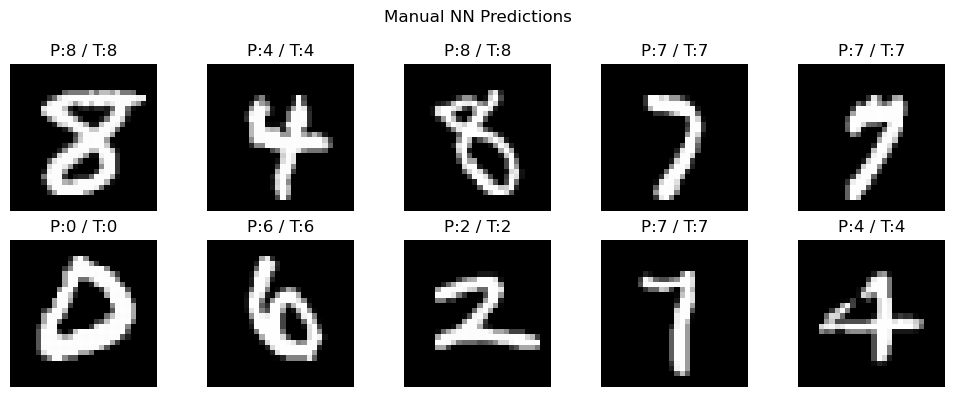


Training Scikit-Learn MLPClassifier...


C:\Users\fulvi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


Scikit-Learn MLP test accuracy: 0.9724


In [13]:
if __name__ == "__main__":
    #1: Manual classification
    classification_manual()

    #2: Parameter testing (optional)
    #part_d_and_e_analysis(*load_mnist_dataset())

    #3: Comparison with Scikit-Learn
    classification_sklearn()